## Decision Tree Classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
iris=load_iris()
X=iris.data #type:ignore
y=iris.target #type:ignore

feature_names=iris.feature_names #type:ignore
target_names=iris.target_names #type:ignore

In [2]:
# Convert to DataFrame
df=pd.DataFrame(X, columns=feature_names)
df["target"]=y

print("First 5 rows:", df.head())
print("Info:", df.info())
print("Summary:", df.describe())

First 5 rows:    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: fl

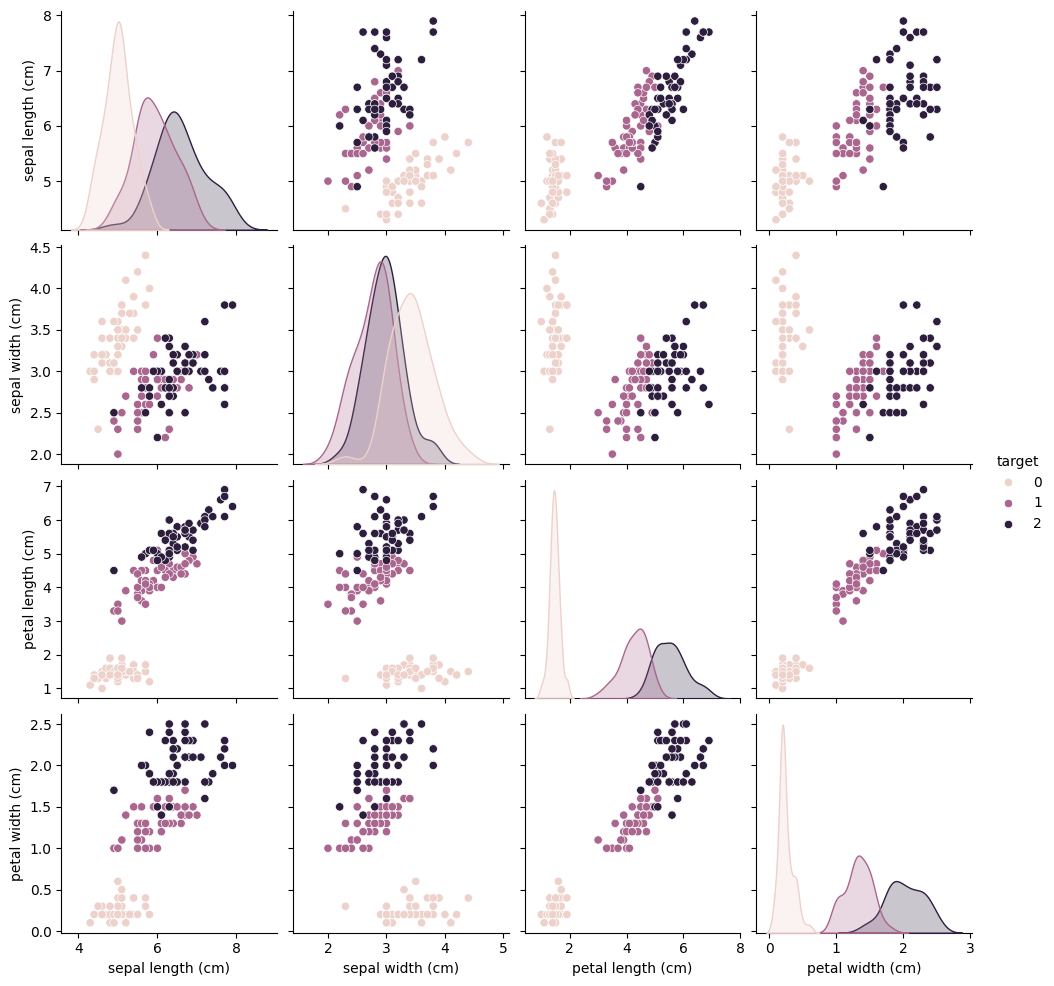

In [3]:
# Visualization
sns.pairplot(df, hue="target")
plt.show()

In [4]:
# Data Preparation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Model Building
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [6]:
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred=model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



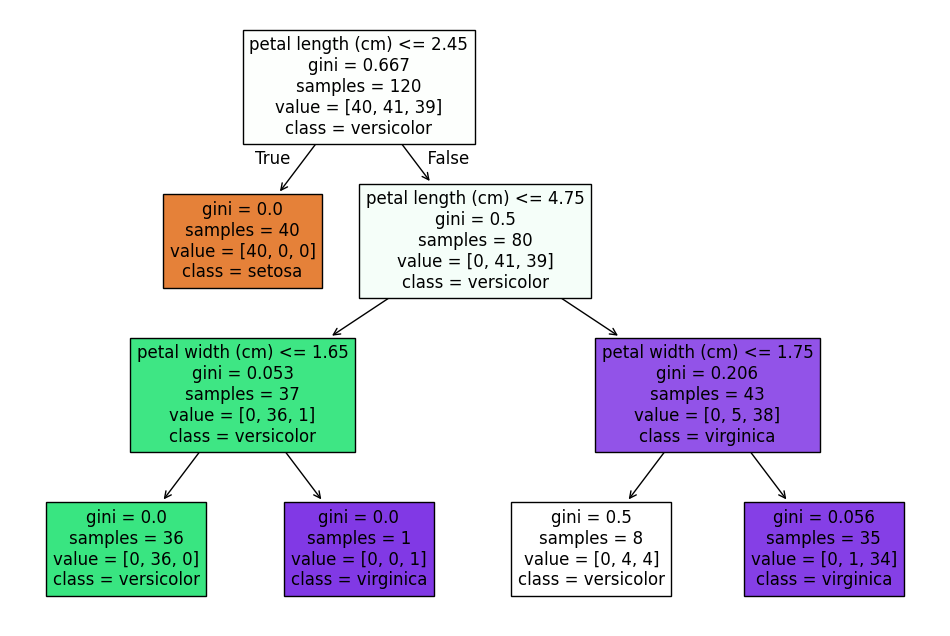

In [7]:
# Tree Visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    model, 
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)
plt.show()

In [8]:
# Feature Importance
importances=model.feature_importances_

for name, importance in zip(feature_names, importances):
    print(f"{name}:{importance:.4f}")

sepal length (cm):0.0000
sepal width (cm):0.0000
petal length (cm):0.9346
petal width (cm):0.0654


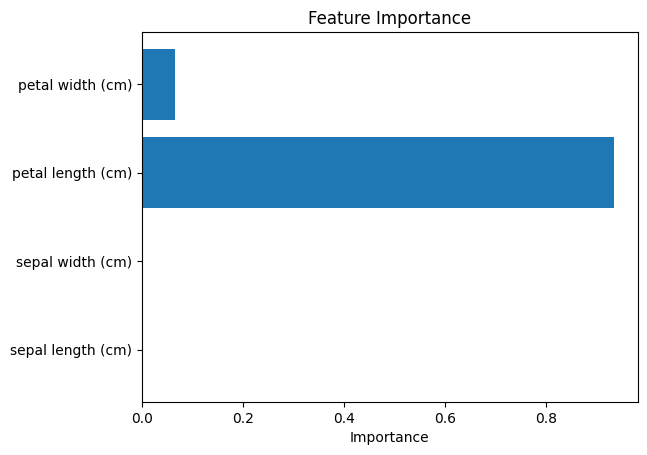

In [9]:
# Visualization
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [10]:
# Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid={
    "max_depth":[2, 3,4,5],
    "criterion":["gini", "entropy"],
    "min_samples_split":[2,5,10]
}

grid=GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
    )

grid.fit(X_train, y_train)

print("Best param:", grid.best_params_)

Best param: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}


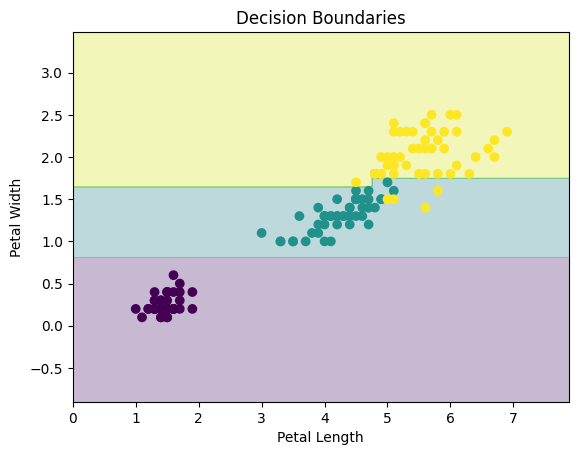

In [11]:
# Decision Boundary Visualization (2 features only)

from matplotlib.colors import ListedColormap

X_small=X[:, [2,3]] #petal length & width

X_train_s, X_test_s, y_train_s, y_test_s=train_test_split(
    X_small, y, test_size=0.2, random_state=42
)
model_small=DecisionTreeClassifier(max_depth=3)
model_small.fit(X_train_s, y_train_s)

# Meshgrid
x_min, x_max=X_small[:,0].min()-1, X_small[:,0].max()+1
y_min, y_max=X_small[:, 1].min()-1, X_small[:, 1].max()+1

xx, yy=np.meshgrid(np.arange(x_min, x_max, 0.02),
                   np.arange(y_min, y_max, 0.02))

Z=model_small.predict(np.c_[xx.ravel(), yy.ravel()])
Z=Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_small[:, 0], X_small[:, 1], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundaries")
plt.show()